## Model Convergence and Stability Analysis
The following learning curves visualize the training process of the ECGCNN over 50 epochs. We observe a high degree of volatility in the initial 30 epochs, which represents the model's feature-discovery phase.

#### Key Observations:

**Convergence:** Following the activation of the StepLR scheduler at Epoch 30 (reducing the learning rate by 50%), the Validation Accuracy and Training Loss show immediate stabilization.

**Overfitting Check:** The narrow gap between the training and validation lines suggests that the model is generalizing effectively

**Clinical Reliability:** The stability reached in the final 10 epochs provides the necessary confidence to deploy this model for real-time inference on new patient ECG digitized signals.

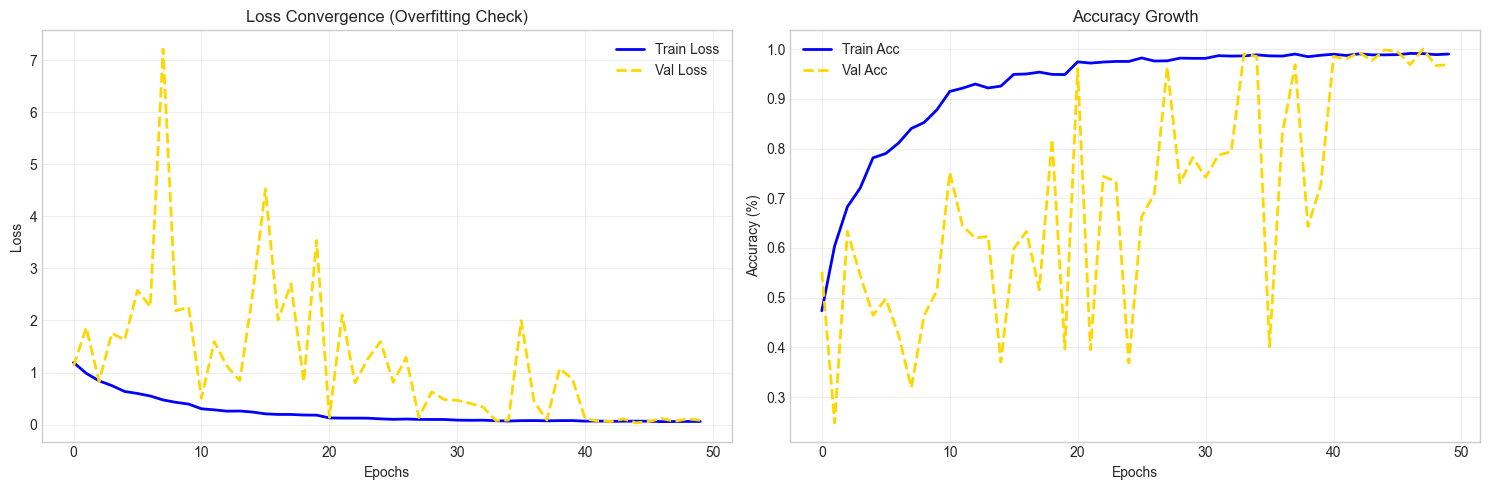

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the history
history = pd.read_csv("../outputs/training_metrics.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Curve Plot
ax1.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
ax1.plot(history['val_loss'], label='Val Loss', color='#FFD700', lw=2, linestyle='--') # Gold Yellow
ax1.set_title('Loss Convergence (Overfitting Check)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy Curve Plot
ax2.plot(history['train_acc'], label='Train Acc', color='blue', lw=2)
ax2.plot(history['val_acc'], label='Val Acc', color='#FFD700', lw=2, linestyle='--') # Gold Yellow
ax2.set_title('Accuracy Growth')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

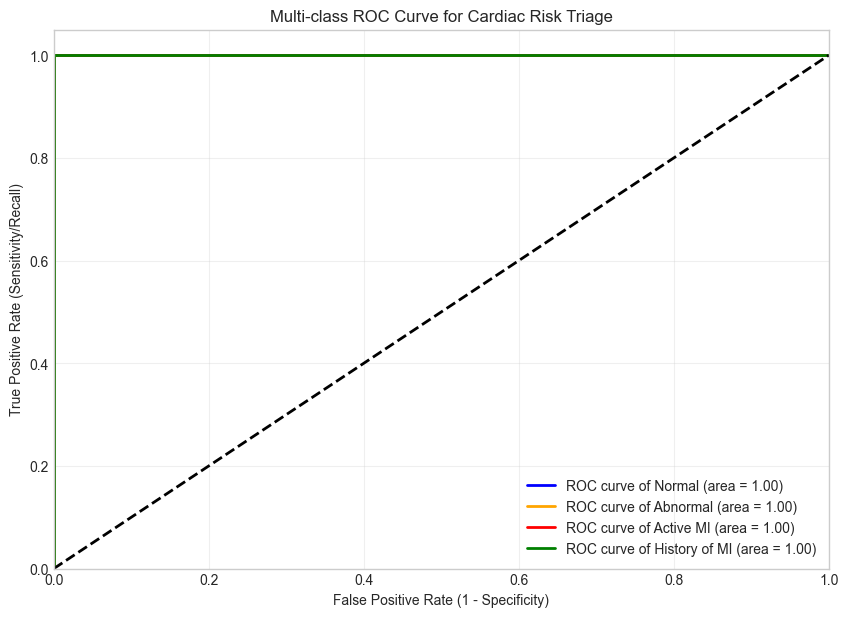

In [34]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load the saved evaluation data
data = torch.load("../outputs/eval_data.pth", weights_only=False)
y_true = np.array(data['targets'])
y_probs = np.array(data['probs'])
class_names = ['Normal', 'Abnormal', 'Active MI', 'History of MI']
n_classes = len(class_names)

# Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

plt.figure(figsize=(10, 7))
colors = ['blue', 'orange', 'red', 'green']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Multi-class ROC Curve for Cardiac Risk Triage')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()